# **AB Testing on Marketing Data**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Loading dataset:

df = pd.read_csv("marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
# Exploring Dataset:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [ ]:
# Observation: "Unnamed: 0" is not required for analysis, so we drop it.

df.drop(columns=['Unnamed: 0'], inplace = True)
df.columns

Index(['user id', 'test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [ ]:
# Next we check the groups in dataset:

df['test group'].value_counts()

,count
test group,
ad,564577
psa,23524


In [ ]:
# We get two groups in data, checking the conversion rate group-wise.

conversion_summary = (
    df
    .groupby('test group')['converted']
    .agg(['count', 'mean'])
    .rename(columns={'mean': 'conversion_rate'})
)

conversion_summary

,count,conversion_rate
test group,,
ad,564577,0.025547
psa,23524,0.017854


In [ ]:
# Exploring other columns:

df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


<Axes: >

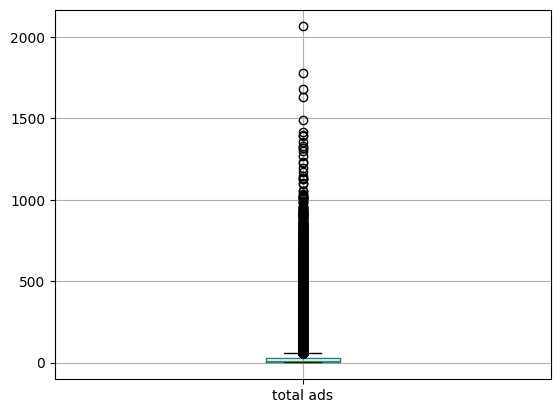

In [ ]:
# Observation: total ads column is heavily skewed i.e. some users see very less ads while some see significantly large amount of ads.

# Outlier Check:

df.boxplot(column='total ads')

In [ ]:
#IQR METHOD FOR OUTLIER REMOVAL
Q3 = df['total ads'].quantile(0.75)
Q1 = df['total ads'].quantile(0.25)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_trimmed = df[df['total ads'] <= upper_bound]

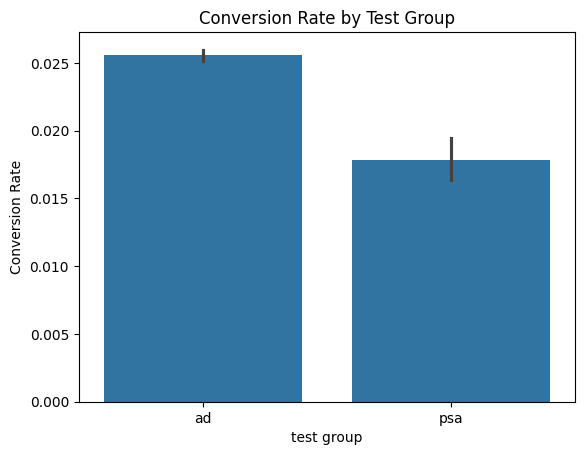

In [ ]:
# Visualising the distribution:

sns.barplot(
    data=df,
    x='test group',
    y='converted',
    estimator=lambda x: sum(x)/len(x)
)

plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Test Group")
plt.show()

In [ ]:
# We convert the converted column, which is boolean, to an integer format for easier analysis.

df['converted_int'] = df['converted'].astype(int)

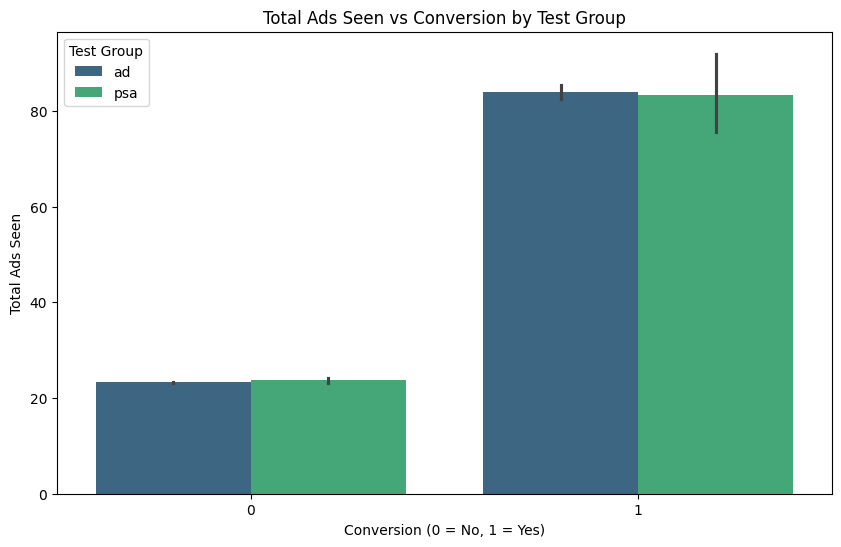

In [ ]:
# Total Ads with Conversion [legend = type of group]

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='converted_int', y='total ads', hue='test group', palette='viridis')
plt.title('Total Ads Seen vs Conversion by Test Group')
plt.xlabel('Conversion (0 = No, 1 = Yes)')
plt.ylabel('Total Ads Seen')
plt.legend(title='Test Group')
plt.show()

In [ ]:
# Grouped Data Analysis: We aggregate the data by test group and the day with the most ads to calculate the mean total ads and the sum of conversions.

grouped_df = df.groupby(["test group", "most ads day"]).agg({"total ads": "mean", "converted_int": "sum"}).reset_index()
grouped_df.head()

,test group,most ads day,total ads,converted_int
0,ad,Friday,26.682574,1995
1,ad,Monday,25.389764,2778
2,ad,Saturday,25.126812,1679
3,ad,Sunday,24.369140,2027
4,ad,Thursday,23.267613,1711


### Hypothesis Testing for A/B Test

Given the conversion rates, we need to perform a statistical test to determine if the difference between the 'ad' group and 'psa' group is statistically significant. We will use a Z-test for proportions.

**Null Hypothesis (H0)**: There is no significant difference in conversion rates between the 'ad' group and the 'psa' group. (P_ad = P_psa)

**Alternative Hypothesis (H1)**: There is a significant difference in conversion rates between the 'ad' group and the 'psa' group. (P_ad != P_psa)

### Statistical Assumptions

- Outcome variable is binary (conversion)
- Large sample size ensures normality of sampling distribution (CLT)
- Independent observations
- Two-proportion Z-test is appropriate

Normality of raw data is not required for proportion-based hypothesis testing.


In [ ]:
# Extract data for the 'ad' and 'psa' groups from the conversion_summary

n_ad = conversion_summary.loc['ad', 'count']
x_ad = round(conversion_summary.loc['ad', 'conversion_rate'] * n_ad)
p_ad = conversion_summary.loc['ad', 'conversion_rate']

n_psa = conversion_summary.loc['psa', 'count']
x_psa = round(conversion_summary.loc['psa', 'conversion_rate'] * n_psa)
p_psa = conversion_summary.loc['psa', 'conversion_rate']

print(f"Ad Group: Total Users = {n_ad}, Converted Users = {x_ad}, Conversion Rate = {p_ad:.4f}")
print(f"PSA Group: Total Users = {n_psa}, Converted Users = {x_psa}, Conversion Rate = {p_psa:.4f}")

Ad Group: Total Users = 564577, Converted Users = 14423, Conversion Rate = 0.0255
PSA Group: Total Users = 23524, Converted Users = 420, Conversion Rate = 0.0179


Now, we will perform the Z-test for proportions. We will use the `proportions_ztest` function from the `statsmodels.stats.proportion` module.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

def run_proportion_ztest(df, group_col, outcome_col, group_a, group_b, alpha=0.05):

    conv_a = df[df[group_col] == group_a][outcome_col].sum()
    conv_b = df[df[group_col] == group_b][outcome_col].sum()

    n_a = df[df[group_col] == group_a].shape[0]
    n_b = df[df[group_col] == group_b].shape[0]

    counts = [conv_a, conv_b]
    nobs = [n_a, n_b]

    z_stat, p_value = proportions_ztest(counts, nobs)

    result = {
        "group_a": group_a,
        "group_b": group_b,
        "conv_rate_a": conv_a / n_a,
        "conv_rate_b": conv_b / n_b,
        "uplift": (conv_a / n_a) - (conv_b / n_b),
        "z_stat": z_stat,
        "p_value": p_value,
        "significant": p_value < alpha
    }

    return result


In [ ]:
# Applying on trimmed dataset:

result_trim = run_proportion_ztest(
    df=df_trimmed,
    group_col='test group',
    outcome_col='converted',
    group_a='ad',
    group_b='psa'
)

result_trim

{'group_a': 'ad',
 'group_b': 'psa',
 'conv_rate_a': np.float64(0.013384079764374918),
 'conv_rate_b': np.float64(0.010596399099774943),
 'uplift': np.float64(0.0027876806645999747),
 'z_stat': np.float64(3.4859086419622503),
 'p_value': np.float64(0.000490468476045044),
 'significant': np.True_}

In [ ]:
print(f"""
A/B Test Results (Trimmed Data)

Ad Conversion Rate   : {result_trim['conv_rate_a']:.4f}
PSA Conversion Rate  : {result_trim['conv_rate_b']:.4f}
Absolute Uplift      : {result_trim['uplift']:.4f}

Z-statistic          : {result_trim['z_stat']:.3f}
P-value              : {result_trim['p_value']:.6f}

Statistically Significant → {result_trim['significant']}
""")



A/B Test Results (Trimmed Data)

Ad Conversion Rate   : 0.0134
PSA Conversion Rate  : 0.0106
Absolute Uplift      : 0.0028

Z-statistic          : 3.486
P-value              : 0.000490

Statistically Significant → True



In [ ]:
# Lets check it for original dataset:

result_full = run_proportion_ztest(
    df=df,
    group_col='test group',
    outcome_col='converted',
    group_a='ad',
    group_b='psa'
)

pd.DataFrame([result_full, result_trim], index=['Full Data', 'Trimmed Data'])


,group_a,group_b,conv_rate_a,conv_rate_b,uplift,z_stat,p_value,significant
Full Data,ad,psa,0.025547,0.017854,0.007692,7.370078,1.705281e-13,True
Trimmed Data,ad,psa,0.013384,0.010596,0.002788,3.485909,4.904685e-04,True


### Sensitivity Analysis

To validate robustness, the A/B test was repeated after removing extreme ad exposure users using the IQR method.  
While the magnitude of uplift decreased, the direction and statistical significance remained consistent.

This indicates that:
- Results are not driven by outliers
- Ads provide a positive conversion lift for the core user base
- Extreme users amplify, but do not create, the observed effect


## Conclusion:

In this analysis, I explored the effectiveness of advertisements versus public service announcements (PSAs). Our findings from exploratory data analysis (EDA) revealed higher purchase probabilities among users exposed to ads. Hypothesis testing further validated these differences, emphasizing the significant impact of targeted advertising on purchase behavior. By integrating EDA with robust statistical methods, we underscored the pivotal role of ads in shaping consumer decisions, providing valuable insights for optimizing future marketing strategies.




